# XWorld — Dataset 2: Sunspot Cycles

**Goal**: Download monthly sunspot numbers (1749–present), slice into individual ~11-year cycles, z-score normalize, extract 7 shape features.

**Dynamic type**: Regular cyclic oscillation with amplitude drift

In [10]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


## 1. Download

In [11]:
URL = 'https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv'
dest = RAW_DIR / 'sunspot_monthly.csv'

if not dest.exists():
    print('Downloading...')
    r = requests.get(URL)
    dest.write_bytes(r.content)
    print(f'Saved to {dest}')
else:
    print(f'Already exists: {dest}')

Already exists: ../data/raw/sunspot_monthly.csv


## 2. Parse

In [12]:
df = pd.read_csv(
    dest,
    sep=';',
    header=None,
    names=['year', 'month', 'decimal_year', 'sunspot_number', 'std_dev', 'n_obs', 'provisional'],
    na_values=['-1']
)

# Replace negatives (missing) with NaN, then forward fill
df['sunspot_number'] = df['sunspot_number'].clip(lower=0)
series_full = df['sunspot_number'].ffill().values

print(f'Total months: {len(series_full)}')
print(f'Date range: {df.year.min()} to {df.year.max()}')
print(f'Min: {series_full.min():.1f}, Max: {series_full.max():.1f}')

Total months: 3326
Date range: 1749 to 2026
Min: 0.0, Max: 398.2


## 3. Plot the full series

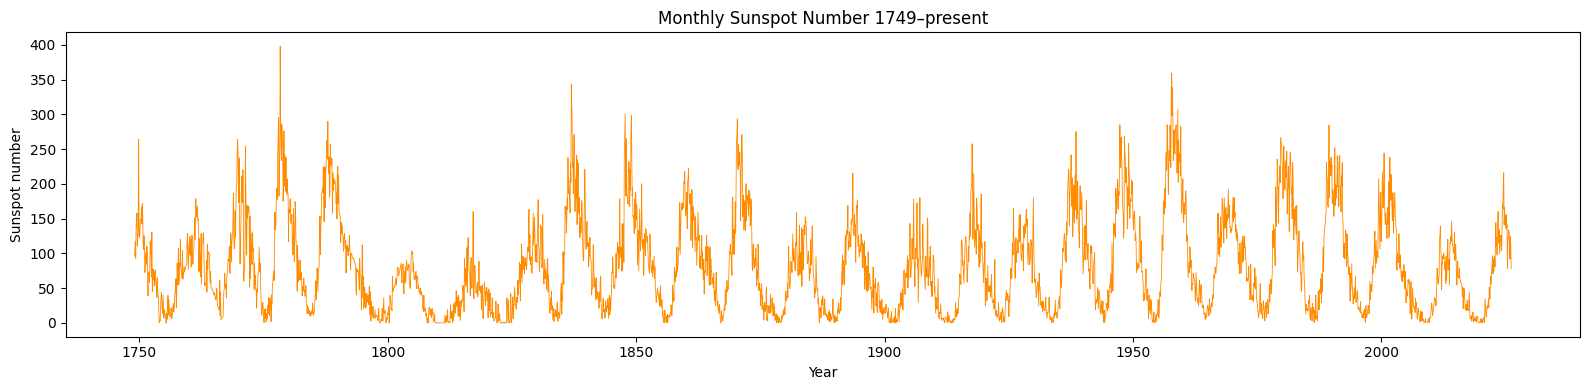

In [13]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['decimal_year'], series_full, linewidth=0.6, color='darkorange')
ax.set_title('Monthly Sunspot Number 1749–present', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Sunspot number')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sunspot_full_series.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Slice into individual cycles

Each solar cycle runs from one minimum to the next — roughly 11 years (~132 months).
Strategy: find all local minima in the smoothed series, use them as cycle boundaries.

Cycle boundaries found: 25
Approximate cycle lengths (months): [122 115 106 164 149 149 129 123 148 132 138 129 147 134 124 127 125 121
 127 134 121 125 145 130]


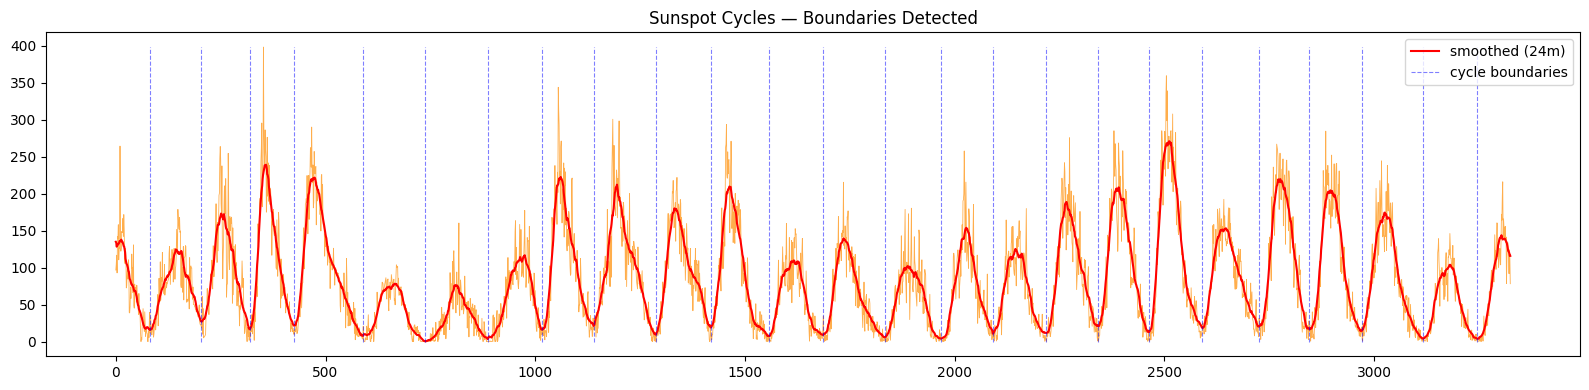

In [14]:
from scipy.ndimage import uniform_filter1d

# Smooth to find cycle minima (suppress monthly noise)
smoothed = uniform_filter1d(series_full.astype(float), size=24)

# Find minima: valleys in the smoothed series, min distance ~80 months apart
# Invert to use find_peaks on minima
minima, _ = find_peaks(-smoothed, distance=80, prominence=20)

print(f'Cycle boundaries found: {len(minima)}')
print(f'Approximate cycle lengths (months): {np.diff(minima)}')

# Visualize boundaries on full series
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(series_full, linewidth=0.6, color='darkorange', alpha=0.7)
ax.plot(smoothed, linewidth=1.5, color='red', label='smoothed (24m)')
ax.vlines(minima, 0, series_full.max(), color='blue', linewidth=0.8, linestyle='--', alpha=0.5, label='cycle boundaries')
ax.set_title('Sunspot Cycles — Boundaries Detected', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sunspot_cycle_boundaries.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Extract individual cycles

Usable cycles: 24


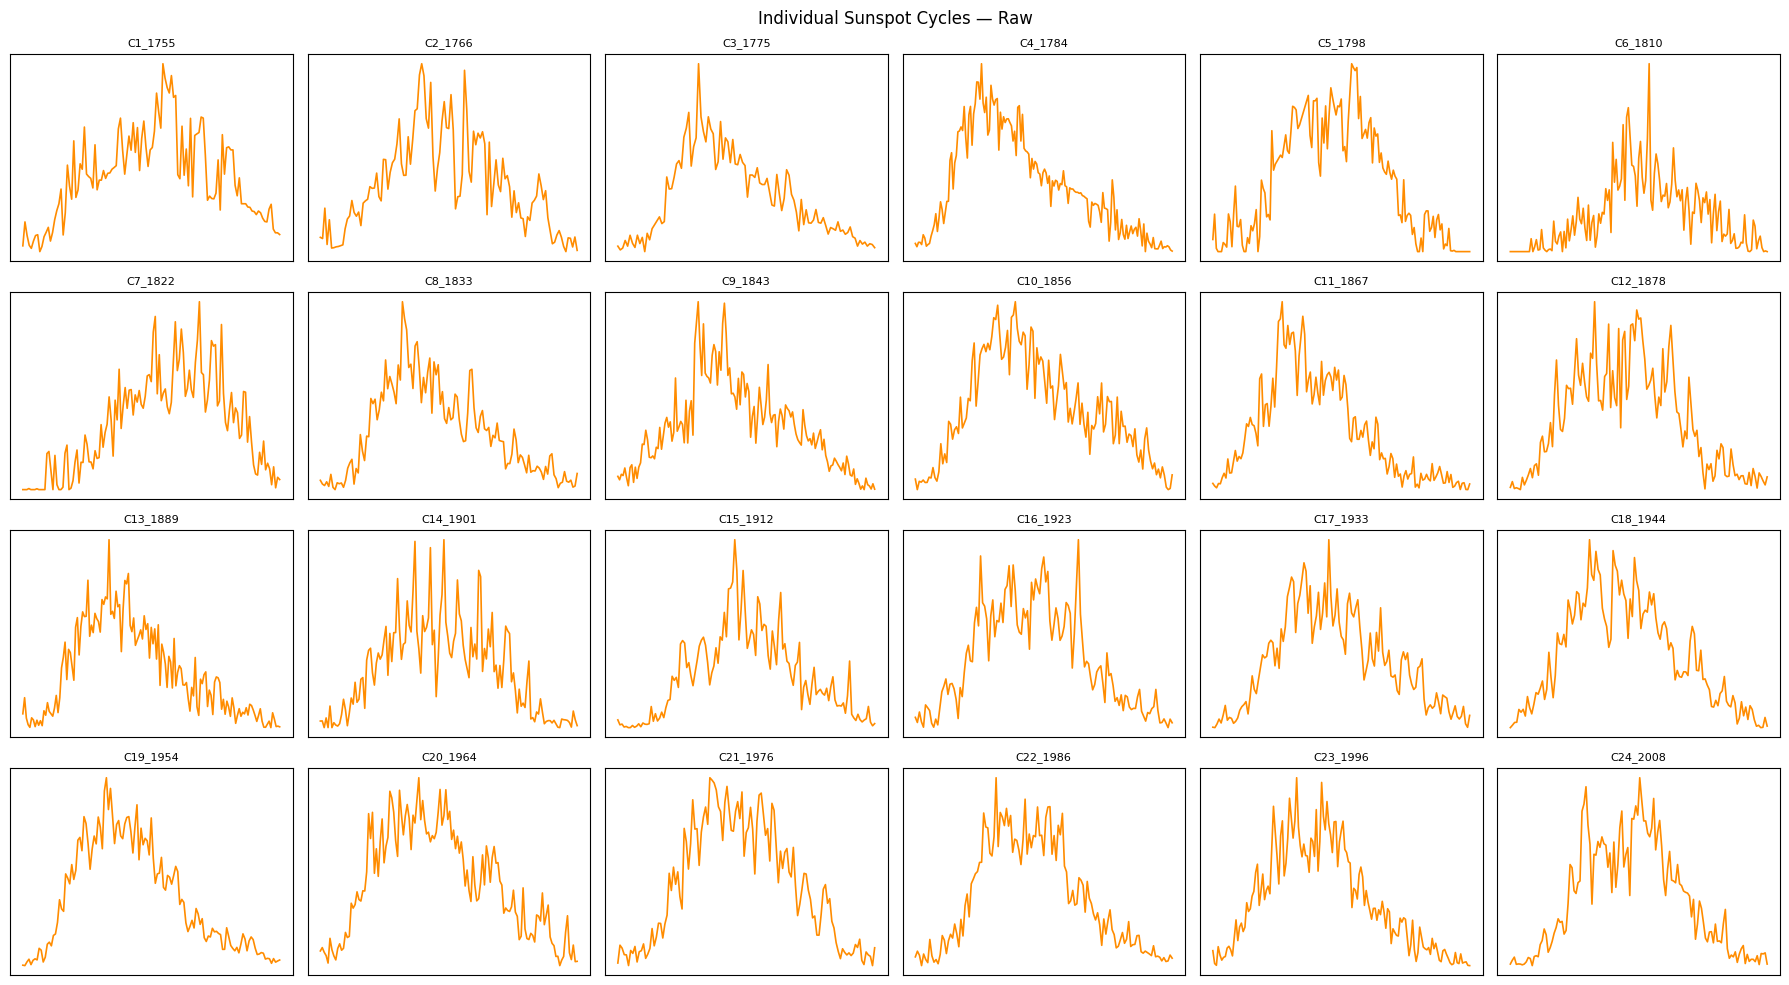

In [15]:
cycles = {}
for i in range(len(minima) - 1):
    start = minima[i]
    end = minima[i + 1]
    cycle = series_full[start:end]
    if len(cycle) >= 80:  # only keep cycles of reasonable length
        cycle_num = i + 1
        start_year = int(df['year'].iloc[start])
        cycles[f'cycle_{cycle_num}_{start_year}'] = cycle

print(f'Usable cycles: {len(cycles)}')

# Plot all raw cycles
fig, axes = plt.subplots(4, 6, figsize=(18, 10))
axes = axes.flatten()
for i, (name, cycle) in enumerate(cycles.items()):
    if i >= len(axes): break
    axes[i].plot(cycle, color='darkorange', linewidth=1.2)
    axes[i].set_title(name.replace('cycle_', 'C'), fontsize=8)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Individual Sunspot Cycles — Raw', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sunspot_cycles_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Z-score normalize and overlay

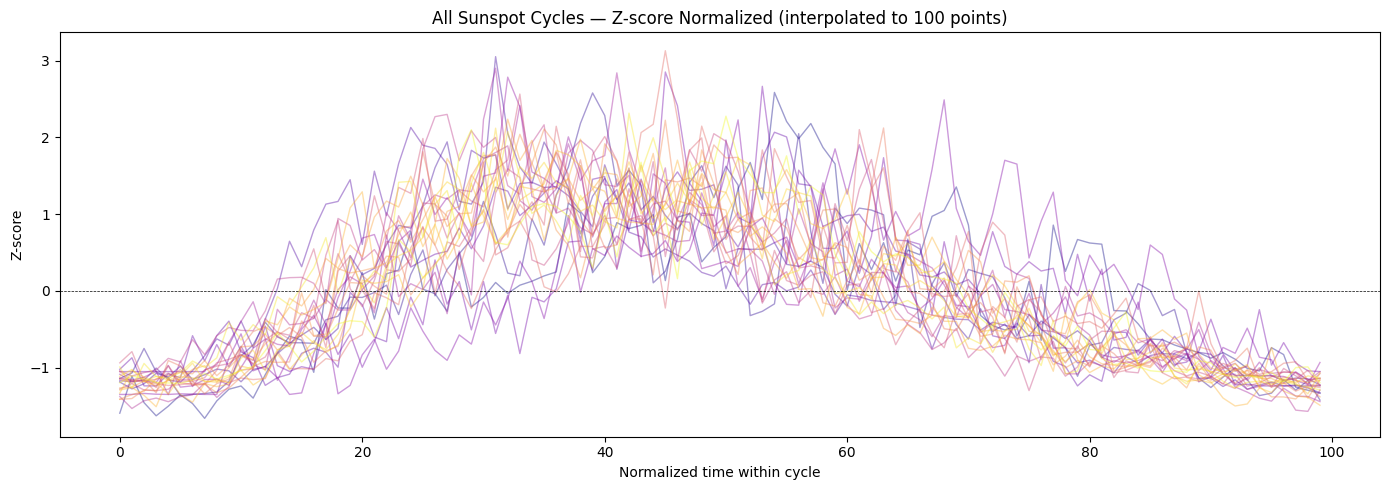

In [16]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

cycles_norm = {name: zscore_normalize(cycle) for name, cycle in cycles.items()}

fig, ax = plt.subplots(figsize=(14, 5))
colors = cm.plasma(np.linspace(0, 1, len(cycles_norm)))
for (name, cycle), color in zip(cycles_norm.items(), colors):
    x = np.linspace(0, 1, len(cycle))
    x_new = np.linspace(0, 1, 100)
    ax.plot(np.interp(x_new, x, cycle), alpha=0.4, linewidth=1.0, color=color)

ax.set_title('All Sunspot Cycles — Z-score Normalized (interpolated to 100 points)', fontsize=12)
ax.set_xlabel('Normalized time within cycle')
ax.set_ylabel('Z-score')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sunspot_cycles_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Extract 7 shape features

In [17]:
def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zero_crossings = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean':           series.mean(),
        'std':            series.std(),
        'skewness':       stats.skew(series),
        'kurtosis':       stats.kurtosis(series),
        'lag1_autocorr':  lag1,
        'zero_crossings': zero_crossings,
        'slope':          slope,
    }

records = []
for name, cycle in cycles_norm.items():
    feats = extract_features(cycle)
    feats['country'] = name
    feats['dataset'] = 'sunspot_cycle'
    feats['n_points'] = len(cycle)
    records.append(feats)

df_features = pd.DataFrame(records)
print(f'Feature matrix shape: {df_features.shape}')
df_features.head()

Feature matrix shape: (24, 10)


,mean,std,skewness,kurtosis,lag1_autocorr,zero_crossings,slope,country,dataset,n_points
0,5.278109e-17,1.0,0.339504,-0.567531,0.806200,0.180328,0.004277,cycle_1_1755,sunspot_cycle,122
1,-2.896234e-17,1.0,0.594121,-0.349038,0.828882,0.156522,-0.002692,cycle_2_1766,sunspot_cycle,115
2,7.541138e-17,1.0,0.656328,-0.316540,0.904901,0.056604,-0.007672,cycle_3_1775,sunspot_cycle,106
3,0.000000e+00,1.0,0.489582,-0.892995,0.938650,0.060976,-0.010037,cycle_4_1784,sunspot_cycle,164
4,9.537486e-17,1.0,0.287177,-1.268658,0.923276,0.040268,-0.003247,cycle_5_1798,sunspot_cycle,149


## 8. Save

In [18]:
out_path = PROCESSED_DIR / 'features_sunspot_cycles.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

feature_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print('\nShape feature summary:')
print(df_features[feature_cols].describe().round(3))

Saved: ../data/processed/features_sunspot_cycles.csv

Shape feature summary:
       skewness  kurtosis  lag1_autocorr  zero_crossings   slope
count    24.000    24.000         24.000          24.000  24.000
mean      0.486    -0.680          0.886           0.095  -0.004
std       0.230     0.674          0.055           0.045   0.005
min       0.111    -1.370          0.720           0.016  -0.011
25%       0.337    -1.082          0.874           0.062  -0.008
50%       0.437    -0.866          0.902           0.082  -0.005
75%       0.599    -0.438          0.924           0.133  -0.003
max       1.221     1.839          0.953           0.180   0.010


---
## Status
- Sunspot cycles extracted and features saved
- Next: `03_lynx_hare_pipeline.ipynb` — predator-prey oscillation